# Preparação de Dados: Airbnb Lisboa

Projeto Prático 1: Machine Learning

Pipeline: carregamento → limpeza → deteção de outliers → seleção de variáveis
→ engenharia de features → split → tratamento de outliers → imputação →
codificação → escala → matriz final.

## 0. Configuração

In [1]:
import pandas as pd
import numpy as np
import ast
import os
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

SEED = 42
INPUT_PATH = "listings.csv.gz"

## 1. Carregar os dados

In [2]:
df = pd.read_csv(INPUT_PATH)
print("Shape:", df.shape)
df.head()

Shape: (24876, 90)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,...,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,6499,https://www.airbnb.com/rooms/6499,20260623040800,2026-07-02,city scrape,Belém 1 Bedroom Historical Apartment,"This apartment is all about Location, next to ...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,14455,https://www.airbnb.com/users/show/14455,1.462507e+18,https://www.airbnb.com/users/profile/146250675...,Bruno,NaN,...,2026-06-14,4.50,4.44,4.36,4.84,4.88,4.81,4.37,NaN,NaN,1,1,0,0,0.83
1,25659,https://www.airbnb.com/rooms/25659,20260623040800,2026-06-26,city scrape,Heart of Lisbon Alfama. Flexible check in times,Cozy apartment in Lisbon's most historic and b...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,107347,https://www.airbnb.com/users/show/107347,1.462510e+18,https://www.airbnb.com/users/profile/146250975...,Ellie,NaN,...,2026-05-28,4.82,4.88,4.86,4.90,4.95,4.86,4.81,56539/AL.,NaN,1,1,0,0,1.57
2,29396,https://www.airbnb.com/rooms/29396,20260623040800,2026-06-25,city scrape,Alfama Hill - Boutique apartment,Feel at home in the historic centre of Lisbon.,NaN,https://a0.muscache.com/pictures/163913/7d622c...,126415,https://www.airbnb.com/users/show/126415,1.462510e+18,https://www.airbnb.com/users/profile/146251026...,Mónica,NaN,...,2026-04-07,4.77,4.80,4.74,4.86,4.91,4.87,4.73,28737/AL,NaN,1,1,0,0,2.59
3,29720,https://www.airbnb.com/rooms/29720,20260623040800,2026-06-25,city scrape,TheHOUSE - Your luxury home,Built by my grandfather to house his big famil...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,128075,https://www.airbnb.com/users/show/128075,1.462510e+18,https://www.airbnb.com/users/profile/146251032...,Francisco,NaN,...,2026-06-13,4.92,4.90,4.87,4.96,4.97,4.86,4.71,55695/AL,NaN,1,1,0,0,0.97
4,29915,https://www.airbnb.com/rooms/29915,20260623040800,2026-06-25,city scrape,Modern and Spacious Apartment in Lisboa,Non-smoking modern and equipped apartment. Qui...,NaN,https://a0.muscache.com/pictures/9b572932-8d23...,128890,https://www.airbnb.com/users/show/128890,1.462510e+18,https://www.airbnb.com/users/profile/146251034...,Sara,NaN,...,2024-05-20,4.57,4.71,4.74,4.77,4.63,4.61,4.54,85851/AL.,NaN,1,1,0,0,0.31


## 2. Valores em falta e colunas 100% vazias

Colunas sem nenhum valor preenchido são removidas de imediato.

In [3]:
info_missing = pd.DataFrame({
    "n_em_falta": df.isna().sum(),
    "pct_em_falta": (df.isna().mean() * 100).round(1),
})
info_missing = info_missing.sort_values("pct_em_falta", ascending=False)
info_missing[info_missing["n_em_falta"] > 0]

,n_em_falta,pct_em_falta
neighborhood_overview,24876,100.0
host_since,24876,100.0
host_response_time,24876,100.0
host_thumbnail_url,24876,100.0
host_acceptance_rate,24876,100.0
host_response_rate,24876,100.0
host_verifications,24876,100.0
neighbourhood,24876,100.0
host_total_listings_count,24876,100.0
host_neighbourhood,24876,100.0


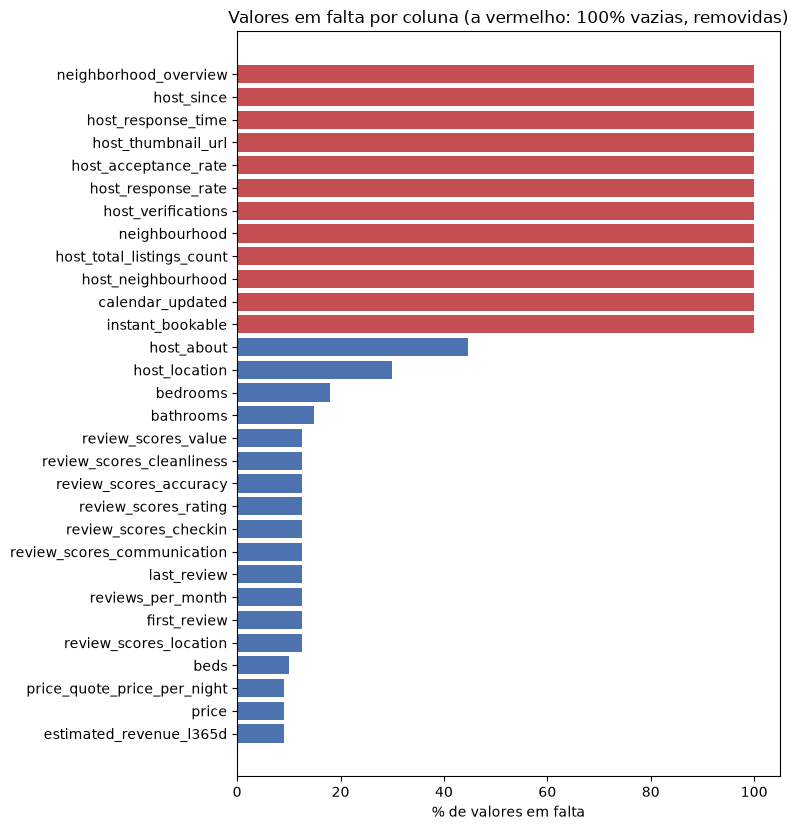

In [4]:
faltas = info_missing[info_missing["n_em_falta"] > 0].head(30)
cores = ["#C44E52" if p == 100 else "#4C72B0" for p in faltas["pct_em_falta"]]
plt.figure(figsize=(8, max(4, 0.28 * len(faltas))))
plt.barh(faltas.index[::-1], faltas["pct_em_falta"].values[::-1], color=cores[::-1])
plt.xlabel("% de valores em falta")
plt.title("Valores em falta por coluna (a vermelho: 100% vazias, removidas)")
plt.tight_layout()
plt.show()

In [5]:
colunas_100_vazias = info_missing[info_missing["pct_em_falta"] == 100].index.tolist()
df = df.drop(columns=colunas_100_vazias)
print(f"{len(colunas_100_vazias)} colunas removidas: {colunas_100_vazias}")
print("Shape:", df.shape)

12 colunas removidas: ['neighborhood_overview', 'host_since', 'host_response_time', 'host_thumbnail_url', 'host_acceptance_rate', 'host_response_rate', 'host_verifications', 'neighbourhood', 'host_total_listings_count', 'host_neighbourhood', 'calendar_updated', 'instant_bookable']
Shape: (24876, 78)


## 3. Limpar o preço (`price`)

In [6]:
def limpar_price(df):
    df = df.copy()
    df["price"] = df["price"].astype(str).str.replace("$", "", regex=False)
    df["price"] = df["price"].str.replace(",", "", regex=False)
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    n_antes = len(df)
    df = df[df["price"] > 0].dropna(subset=["price"])
    print(f"Removidas {n_antes - len(df)} linhas sem preço válido.")
    return df

df = limpar_price(df)
df["price"].describe()

Removidas 2240 linhas sem preço válido.


count    22636.000000
mean       189.788905
std        378.989017
min          3.670000
25%         92.000000
50%        136.000000
75%        200.000000
max      16077.500000
Name: price, dtype: float64

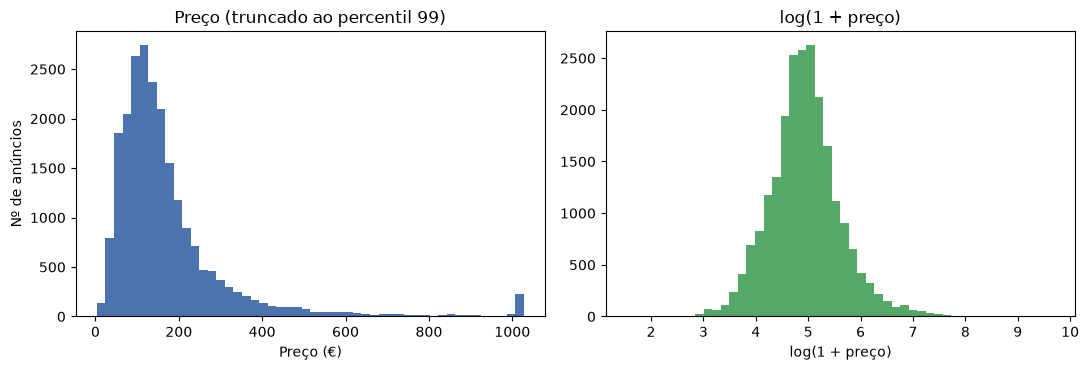

In [7]:
fig, eixos = plt.subplots(1, 2, figsize=(11, 3.8))
eixos[0].hist(df["price"].clip(upper=df["price"].quantile(0.99)), bins=50, color="#4C72B0")
eixos[0].set_title("Preço (truncado ao percentil 99)")
eixos[0].set_xlabel("Preço (€)")
eixos[0].set_ylabel("Nº de anúncios")
eixos[1].hist(np.log1p(df["price"]), bins=50, color="#55A868")
eixos[1].set_title("log(1 + preço)")
eixos[1].set_xlabel("log(1 + preço)")
plt.tight_layout()
plt.show()

## 4. Deteção de outliers

Dois critérios robustos aplicados a `price`, `minimum_nights` e `accommodates`:
- **IQR**: fora de `[Q1 - 1.5×IQR, Q3 + 1.5×IQR]`
- **Z-score**: `|(x - média) / desvio-padrão| > 3`

Apenas deteção/relatório nesta fase; o tratamento é feito após o split
(secção 10), para evitar leakage.

In [8]:
OUTLIER_COLS = ["price", "minimum_nights", "accommodates"]

def limites_iqr(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

def flag_zscore(series, threshold=3):
    z = (series - series.mean()) / series.std()
    return z.abs() > threshold

for col in OUTLIER_COLS:
    lower, upper = limites_iqr(df[col])
    outlier_iqr = (df[col] < lower) | (df[col] > upper)
    outlier_z = flag_zscore(df[col])
    print(f"{col}: IQR={outlier_iqr.sum()}  z-score={outlier_z.sum()}  (limites IQR: {lower:.1f} a {upper:.1f})")

price: IQR=1681  z-score=126  (limites IQR: -70.0 a 362.0)
minimum_nights: IQR=1403  z-score=770  (limites IQR: -2.0 a 6.0)
accommodates: IQR=1643  z-score=437  (limites IQR: -1.0 a 7.0)


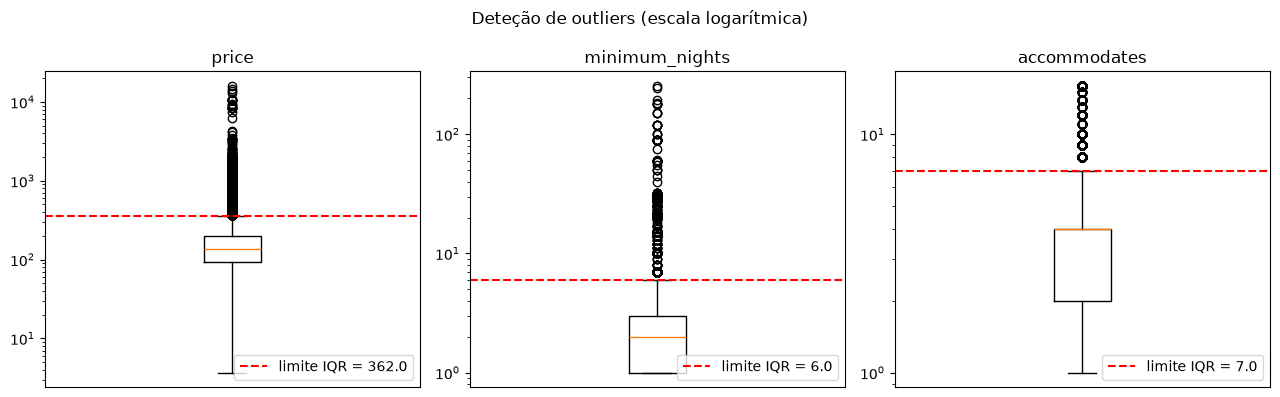

In [9]:
fig, eixos = plt.subplots(1, len(OUTLIER_COLS), figsize=(4.3 * len(OUTLIER_COLS), 4))
for eixo, col in zip(eixos, OUTLIER_COLS):
    eixo.boxplot(df[col].dropna(), whis=1.5)
    eixo.set_yscale("log")
    _, superior = limites_iqr(df[col])
    eixo.axhline(superior, color="red", linestyle="--", label=f"limite IQR = {superior:.1f}")
    eixo.set_title(col)
    eixo.set_xticks([])
    eixo.legend(loc="lower right")
fig.suptitle("Deteção de outliers (escala logarítmica)")
plt.tight_layout()
plt.show()

## 4.1. Correlação de TODAS as variáveis numéricas com o preço

Antes de escolher que colunas manter (secção seguinte), vale a pena ver a
correlação de todas as colunas numéricas disponíveis com o preço.

In [10]:
colunas_numericas_todas = df.select_dtypes(include=[np.number]).columns.tolist()
colunas_numericas_todas = [c for c in colunas_numericas_todas if c != "price"]

corr_todas = df[colunas_numericas_todas + ["price"]].corr(numeric_only=True)["price"].drop("price")
corr_todas.sort_values(key=abs, ascending=False).round(3)

price_quote_price_per_night                     1.000
price_quote_total_price                         0.644
accommodates                                    0.314
bedrooms                                        0.293
bathrooms                                       0.277
beds                                            0.263
estimated_revenue_l365d                         0.202
longitude                                      -0.089
reviews_per_month                              -0.066
estimated_occupancy_l365d                      -0.065
calculated_host_listings_count_private_rooms   -0.064
number_of_reviews_ltm                          -0.056
number_of_reviews_ly                           -0.053
number_of_reviews_l30d                         -0.049
number_of_reviews                              -0.044
calculated_host_listings_count                 -0.033
minimum_minimum_nights                         -0.033
minimum_nights                                 -0.033
minimum_nights_avg_ntm      

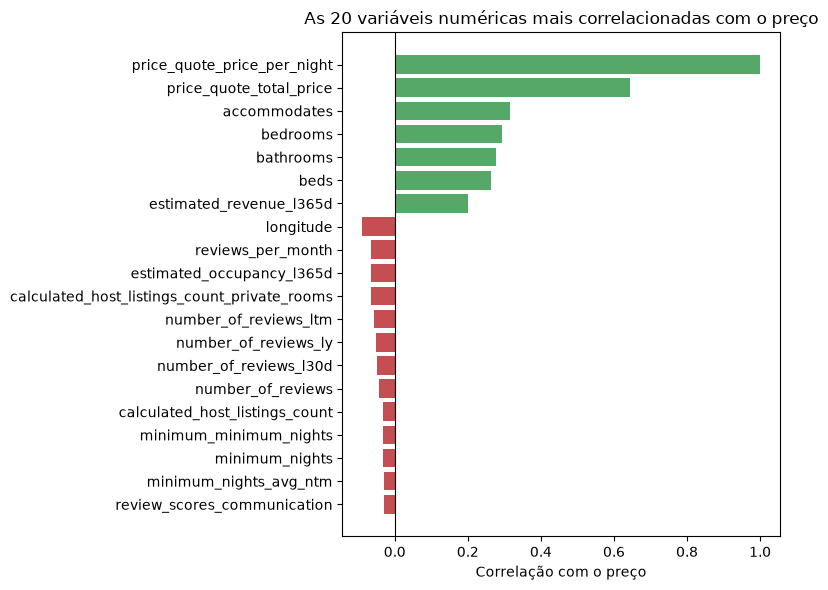

In [11]:
top = corr_todas.reindex(corr_todas.abs().sort_values(ascending=False).head(20).index)
plt.figure(figsize=(8, 6))
plt.barh(top.index[::-1], top.values[::-1], color=np.where(top.values[::-1] > 0, "#55A868", "#C44E52"))
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Correlação com o preço")
plt.title("As 20 variáveis numéricas mais correlacionadas com o preço")
plt.tight_layout()
plt.show()

## 5. Seleção de variáveis

In [12]:
def selecionar_variaveis(df):
    numeric_cols = [c for c in [
        "accommodates", "bedrooms", "bathrooms", "beds",
        "minimum_nights", "number_of_reviews", "review_scores_rating",
        "reviews_per_month", "availability_365",
        "host_response_rate", "host_is_superhost", "instant_bookable",
    ] if c in df.columns]
    categorical_cols = [c for c in ["room_type", "property_type", "neighbourhood_cleansed"] if c in df.columns]
    return numeric_cols, categorical_cols

numeric_cols, categorical_cols = selecionar_variaveis(df)
print("Numericas:", numeric_cols)
print("Categoricas:", categorical_cols)

Numericas: ['accommodates', 'bedrooms', 'bathrooms', 'beds', 'minimum_nights', 'number_of_reviews', 'review_scores_rating', 'reviews_per_month', 'availability_365', 'host_is_superhost']
Categoricas: ['room_type', 'property_type', 'neighbourhood_cleansed']


## 6. Engenharia de features

In [13]:
def limpar_percentagens_e_booleanos(df):
    df = df.copy()
    if "host_response_rate" in df.columns and not pd.api.types.is_numeric_dtype(df["host_response_rate"]):
        df["host_response_rate"] = df["host_response_rate"].astype(str).str.replace("%", "", regex=False)
        df["host_response_rate"] = pd.to_numeric(df["host_response_rate"], errors="coerce")

    bool_mapping = {"t": 1, "f": 0, "true": 1, "false": 0, True: 1, False: 0}
    for col in ["host_is_superhost", "instant_bookable"]:
        if col in df.columns:
            if pd.api.types.is_bool_dtype(df[col]):
                df[col] = df[col].astype(int)
            else:
                df[col] = df[col].astype(str).str.lower().map(bool_mapping)
    return df

df = limpar_percentagens_e_booleanos(df)

In [14]:
def criar_has_reviews(df):
    df = df.copy()
    df["has_reviews"] = (df["number_of_reviews"] > 0).astype(int)
    return df

df = criar_has_reviews(df)
numeric_cols = numeric_cols + ["has_reviews"]

In [15]:
def contar_amenities(cell):
    try:
        return len(ast.literal_eval(cell))
    except Exception:
        return 0

def criar_n_amenities(df):
    df = df.copy()
    df["n_amenities"] = df["amenities"].apply(contar_amenities)
    return df

df = criar_n_amenities(df)
numeric_cols = numeric_cols + ["n_amenities"]

In [16]:
def agrupar_raras(df, col, top_n):
    top_categorias = df[col].value_counts().head(top_n).index
    df[col] = df[col].where(df[col].isin(top_categorias), "Other")
    return df

if "property_type" in df.columns:
    df = agrupar_raras(df, "property_type", top_n=10)
if "neighbourhood_cleansed" in df.columns:
    df = agrupar_raras(df, "neighbourhood_cleansed", top_n=15)

print("property_type:", df["property_type"].nunique(), "categorias")
print("neighbourhood_cleansed:", df["neighbourhood_cleansed"].nunique(), "categorias")

property_type: 11 categorias
neighbourhood_cleansed: 16 categorias


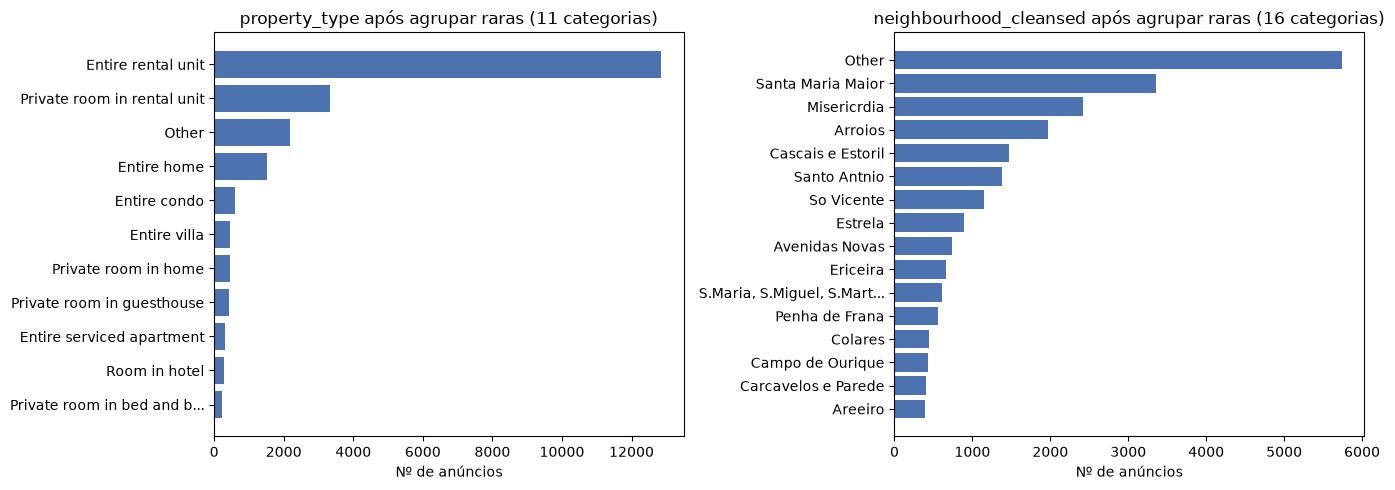

In [17]:
abreviar = lambda s: s if len(s) <= 28 else s[:25] + "..."
colunas_plot = [c for c in ["property_type", "neighbourhood_cleansed"] if c in df.columns]
fig, eixos = plt.subplots(1, len(colunas_plot), figsize=(7 * len(colunas_plot), 5))
for eixo, col in zip(np.atleast_1d(eixos), colunas_plot):
    contagens = df[col].value_counts().sort_values()
    eixo.barh([abreviar(str(c)) for c in contagens.index], contagens.values, color="#4C72B0")
    eixo.set_xlabel("Nº de anúncios")
    eixo.set_title(f"{col} após agrupar raras ({len(contagens)} categorias)")
plt.tight_layout()
plt.show()

In [18]:
# remover candidatas 100% vazias e duplicados (em caso de reexecucao de celulas)
numeric_cols = list(dict.fromkeys(c for c in numeric_cols if not df[c].isna().all()))
print("Numericas finais:", numeric_cols)

Numericas finais: ['accommodates', 'bedrooms', 'bathrooms', 'beds', 'minimum_nights', 'number_of_reviews', 'review_scores_rating', 'reviews_per_month', 'availability_365', 'host_is_superhost', 'has_reviews', 'n_amenities']


## 7. Correlações e médias por categoria

In [19]:
corr = df[numeric_cols + ["price"]].corr(numeric_only=True)["price"].drop("price")
corr.sort_values(key=abs, ascending=False).round(3)

accommodates            0.314
bedrooms                0.293
bathrooms               0.277
beds                    0.263
n_amenities             0.095
reviews_per_month      -0.066
has_reviews            -0.063
number_of_reviews      -0.044
minimum_nights         -0.033
host_is_superhost       0.022
availability_365        0.019
review_scores_rating   -0.018
Name: price, dtype: float64

In [20]:
for col in categorical_cols:
    stats = df.groupby(col)["price"].agg(["mean", "median", "count"]).sort_values("mean", ascending=False).round(1)
    print(f"\n--- {col} ---")
    print(stats)


--- room_type ---
                  mean  median  count
room_type                            
Entire home/apt  222.0   157.0  16881
Hotel room       219.7   168.0    150
Private room      92.9    69.0   5464
Shared room       55.6    34.5    141

--- property_type ---
                                    mean  median  count
property_type                                          
Entire villa                       621.4   423.3    445
Entire home                        330.0   216.0   1529
Entire serviced apartment          211.6   165.5    326
Entire condo                       207.3   169.3    596
Room in hotel                      206.2   160.0    287
Entire rental unit                 198.4   151.7  12858
Private room in bed and breakfast  180.4   102.5    236
Other                              160.1   109.2   2176
Private room in home                93.8    79.9    444
Private room in guesthouse          91.8    80.0    413
Private room in rental unit         72.8    63.0   3326

-

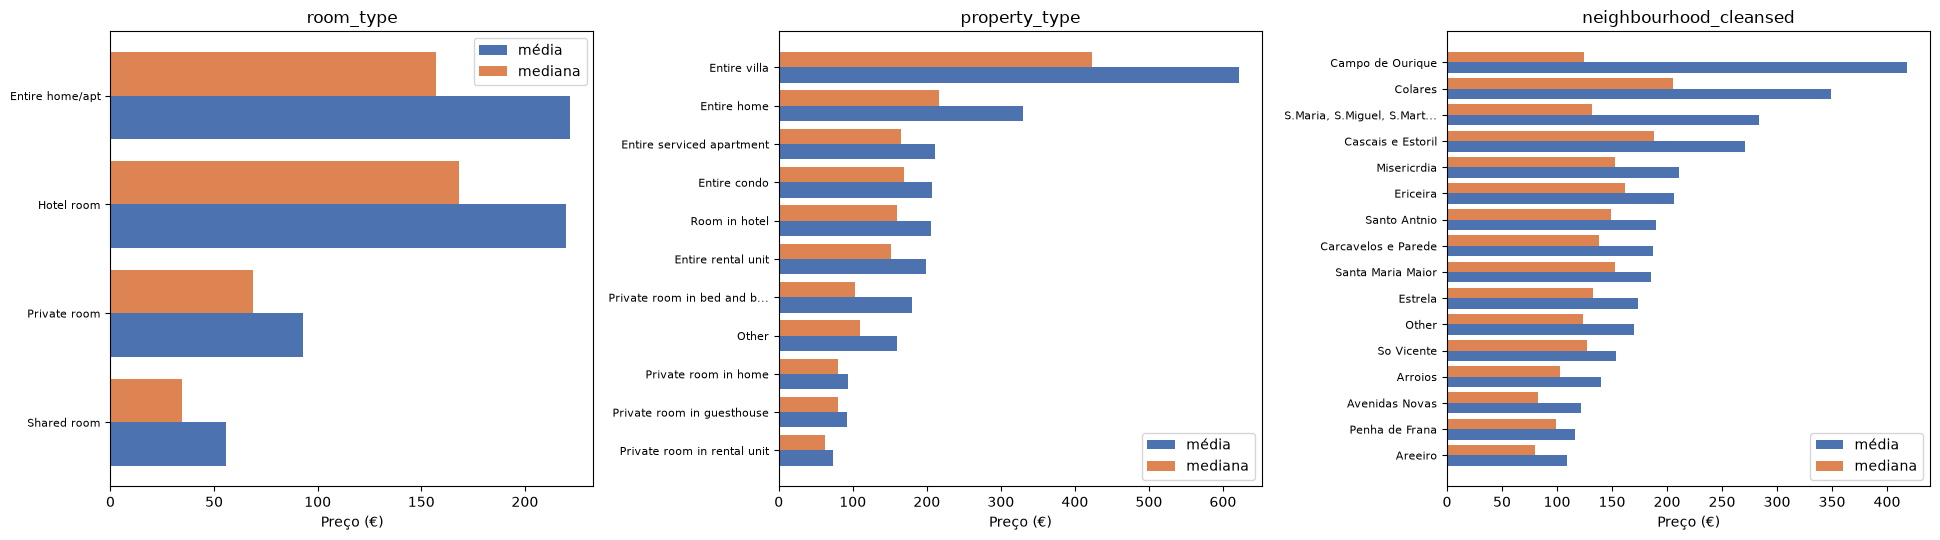

In [21]:
abreviar = lambda s: s if len(s) <= 28 else s[:25] + "..."
fig, eixos = plt.subplots(1, len(categorical_cols), figsize=(6.5 * len(categorical_cols), 5.5))
for eixo, col in zip(np.atleast_1d(eixos), categorical_cols):
    stats = df.groupby(col)["price"].agg(["mean", "median"]).sort_values("mean")
    pos = np.arange(len(stats))
    eixo.barh(pos - 0.2, stats["mean"], height=0.4, label="média", color="#4C72B0")
    eixo.barh(pos + 0.2, stats["median"], height=0.4, label="mediana", color="#DD8452")
    eixo.set_yticks(pos)
    eixo.set_yticklabels([abreviar(str(s)) for s in stats.index], fontsize=8)
    eixo.set_xlabel("Preço (€)")
    eixo.set_title(col)
    eixo.legend()
plt.tight_layout()
plt.show()

## 8. Alvo de classificação (`high_price`)

Classe positiva: top 20% de preço dentro do grupo `room_type` + `neighbourhood_cleansed`.

In [22]:
def definir_target(df, quantile=0.8):
    df = df.copy()
    grupo = ["room_type", "neighbourhood_cleansed"]
    threshold = df.groupby(grupo)["price"].transform(lambda s: s.quantile(quantile))
    df["high_price"] = (df["price"] >= threshold).astype(int)
    return df

df = definir_target(df)
df["high_price"].value_counts(normalize=True).round(3)

high_price
0    0.797
1    0.203
Name: proportion, dtype: float64

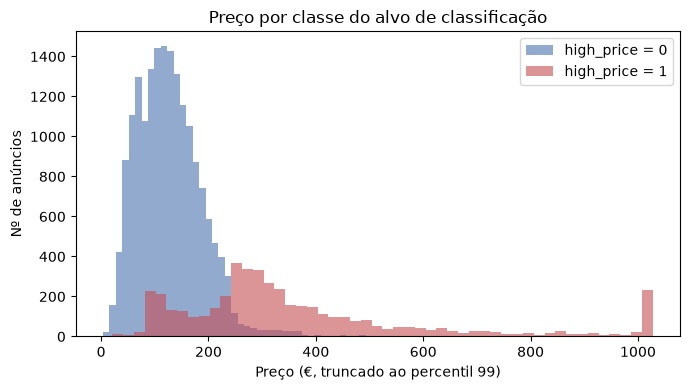

In [23]:
limite_visual = df["price"].quantile(0.99)
fig, ax = plt.subplots(figsize=(7, 4))
for classe, cor in [(0, "#4C72B0"), (1, "#C44E52")]:
    ax.hist(df.loc[df["high_price"] == classe, "price"].clip(upper=limite_visual), bins=50,
            alpha=0.6, color=cor, label=f"high_price = {classe}")
ax.set_xlabel("Preço (€, truncado ao percentil 99)")
ax.set_ylabel("Nº de anúncios")
ax.set_title("Preço por classe do alvo de classificação")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Split treino / validação / teste

Feito antes de qualquer tratamento de outliers, imputação ou escala, para
evitar leakage.

In [24]:
def split_treino_val_teste(df, val_size=0.15, test_size=0.15, seed=SEED):
    df = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    n = len(df)
    n_test = int(n * test_size)
    n_val = int(n * val_size)
    test = df.iloc[:n_test]
    val = df.iloc[n_test:n_test + n_val]
    train = df.iloc[n_test + n_val:]
    return train.reset_index(drop=True), val.reset_index(drop=True), test.reset_index(drop=True)

train, val, test = split_treino_val_teste(df)
print(f"treino: {len(train)}   validação: {len(val)}   teste: {len(test)}")

treino: 15846   validação: 3395   teste: 3395


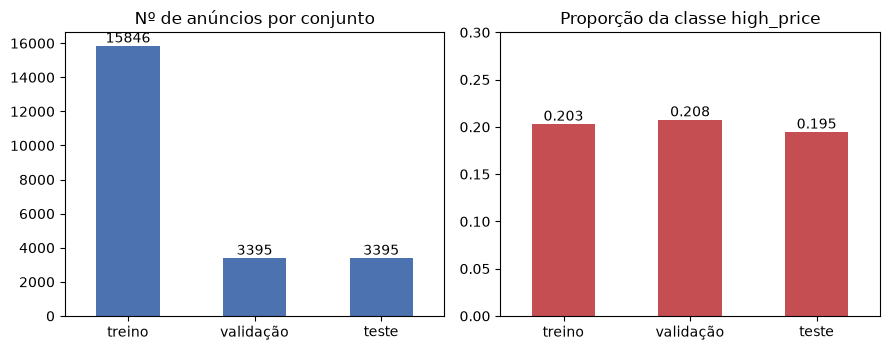

In [25]:
resumo_split = pd.DataFrame({
    "n": [len(train), len(val), len(test)],
    "prop_high_price": [train["high_price"].mean(), val["high_price"].mean(), test["high_price"].mean()],
}, index=["treino", "validação", "teste"])
fig, eixos = plt.subplots(1, 2, figsize=(9, 3.6))
resumo_split["n"].plot(kind="bar", ax=eixos[0], rot=0, color="#4C72B0")
eixos[0].bar_label(eixos[0].containers[0])
eixos[0].set_title("Nº de anúncios por conjunto")
resumo_split["prop_high_price"].plot(kind="bar", ax=eixos[1], rot=0, color="#C44E52")
eixos[1].bar_label(eixos[1].containers[0], fmt="%.3f")
eixos[1].set_ylim(0, 0.3)
eixos[1].set_title("Proporção da classe high_price")
plt.tight_layout()
plt.show()

## 10. Tratamento de outliers

`OUTLIER_STRATEGY`: `"none"` / `"cap"` (winsorização) / `"drop"`.
Limites calculados no treino e reaplicados (`cap`) a val/test.

In [26]:
OUTLIER_STRATEGY = "cap"

In [27]:
preco_treino_antes = train["price"].copy()

def calcular_limites_cap(df, cols):
    return {col: (max(limites_iqr(df[col])[0], 0), limites_iqr(df[col])[1]) for col in cols}

def aplicar_cap(df, limites):
    df = df.copy()
    for col, (lower, upper) in limites.items():
        df[col] = df[col].clip(lower=lower, upper=upper)
    return df

def detectar_outliers_mask(df, cols):
    mask = pd.Series(False, index=df.index)
    for col in cols:
        lower, upper = limites_iqr(df[col])
        mask = mask | (df[col] < lower) | (df[col] > upper) | flag_zscore(df[col])
    return mask

if OUTLIER_STRATEGY == "cap":
    limites = calcular_limites_cap(train, OUTLIER_COLS)
    train = aplicar_cap(train, limites)
    val = aplicar_cap(val, limites)
    test = aplicar_cap(test, limites)
    print("Limites aplicados:", limites)

elif OUTLIER_STRATEGY == "drop":
    mask = detectar_outliers_mask(train, OUTLIER_COLS)
    n_antes = len(train)
    train = train[~mask].copy()
    print(f"Removidas {n_antes - len(train)} linhas do treino.")

else:
    print("Sem tratamento de outliers.")

Limites aplicados: {'price': (0, 362.0), 'minimum_nights': (0, 6.0), 'accommodates': (0, 9.5)}


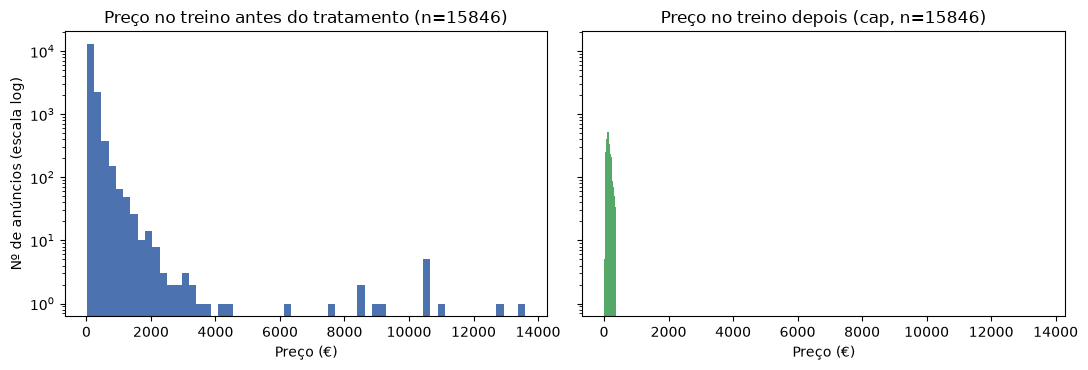

In [28]:
fig, eixos = plt.subplots(1, 2, figsize=(11, 3.8), sharex=True, sharey=True)
eixos[0].hist(preco_treino_antes, bins=60, color="#4C72B0")
eixos[0].set_title(f"Preço no treino antes do tratamento (n={len(preco_treino_antes)})")
eixos[1].hist(train["price"], bins=60, color="#55A868")
eixos[1].set_title(f"Preço no treino depois ({OUTLIER_STRATEGY}, n={len(train)})")
for eixo in eixos:
    eixo.set_yscale("log")
    eixo.set_xlabel("Preço (€)")
eixos[0].set_ylabel("Nº de anúncios (escala log)")
plt.tight_layout()
plt.show()

## 11. Imputação de valores em falta

`MISSING_STRATEGY`: `"simple"` (mediana geral) ou `"grouped"` (mediana por
bairro + tipo de quarto, com fallback para a mediana geral).

In [29]:
MISSING_STRATEGY = "grouped"

In [30]:
def imputar_valores(train, val, test, cols, strategy):
    train, val, test = train.copy(), val.copy(), test.copy()
    if strategy == "simple":
        medianas = train[cols].median()
        train[cols] = train[cols].fillna(medianas)
        val[cols] = val[cols].fillna(medianas)
        test[cols] = test[cols].fillna(medianas)

    elif strategy == "grouped":
        grupo_cols = ["neighbourhood_cleansed", "room_type"]
        medianas_grupo = train.groupby(grupo_cols)[cols].median()
        medianas_globais = train[cols].median()

        def preencher(d):
            d = d.set_index(grupo_cols)
            d[cols] = d[cols].fillna(medianas_grupo)
            d = d.reset_index()
            d[cols] = d[cols].fillna(medianas_globais)
            return d

        train, val, test = preencher(train), preencher(val), preencher(test)

    return train, val, test

faltas_antes = train[numeric_cols].isna().sum()
train, val, test = imputar_valores(train, val, test, numeric_cols, MISSING_STRATEGY)

print("Valores em falta:", train[numeric_cols].isna().sum().sum(),
      val[numeric_cols].isna().sum().sum(), test[numeric_cols].isna().sum().sum())

Valores em falta: 0 0 0


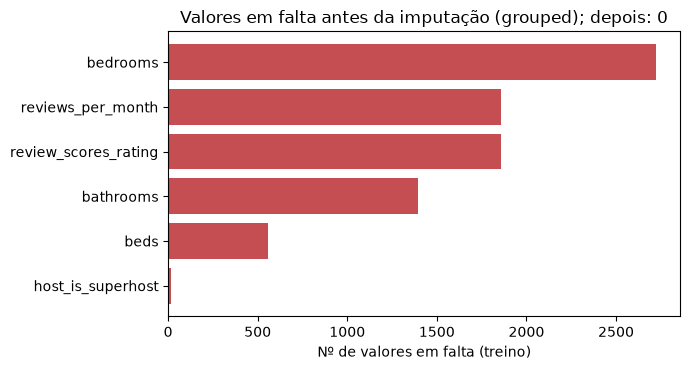

In [31]:
faltas_plot = faltas_antes[faltas_antes > 0].sort_values()
faltas_depois = int(train[numeric_cols].isna().sum().sum())
plt.figure(figsize=(7, 3.8))
if len(faltas_plot) > 0:
    plt.barh(faltas_plot.index, faltas_plot.values, color="#C44E52")
plt.xlabel("Nº de valores em falta (treino)")
plt.title(f"Valores em falta antes da imputação ({MISSING_STRATEGY}); depois: {faltas_depois}")
plt.tight_layout()
plt.show()

## 12. Codificação de variáveis categóricas (one-hot)

In [32]:
def codificar_categoricas(train, val, test, cols):
    train_enc = pd.get_dummies(train, columns=cols)
    val_enc = pd.get_dummies(val, columns=cols)
    test_enc = pd.get_dummies(test, columns=cols)

    train_enc, val_enc = train_enc.align(val_enc, join="left", axis=1, fill_value=0)
    train_enc, test_enc = train_enc.align(test_enc, join="left", axis=1, fill_value=0)
    val_enc = val_enc[train_enc.columns]
    test_enc = test_enc[train_enc.columns]

    colunas_dummy = [c for c in train_enc.columns if any(c.startswith(cat + "_") for cat in cols)]
    return train_enc, val_enc, test_enc, colunas_dummy

train, val, test, colunas_dummy = codificar_categoricas(train, val, test, categorical_cols)
print(f"{len(colunas_dummy)} colunas criadas pelo one-hot encoding")

31 colunas criadas pelo one-hot encoding


## 13. Escala de variáveis numéricas

Standardização (média 0, desvio-padrão 1), estatísticas calculadas só no treino.

In [33]:
def escalar_numericas(train, val, test, cols):
    train, val, test = train.copy(), val.copy(), test.copy()
    media = train[cols].mean()
    desvio = train[cols].std().replace(0, 1.0)
    train[cols] = (train[cols] - media) / desvio
    val[cols] = (val[cols] - media) / desvio
    test[cols] = (test[cols] - media) / desvio
    return train, val, test

# so escalamos as numericas -- as colunas 0/1 do one-hot ficam como estao,
# tanto porque nao faz sentido normalizar binarias como porque assim
# continuam a poder ser usadas depois para agrupar por categoria
colunas_para_escalar = [c for c in numeric_cols if c in train.columns]
antes_escala = train[colunas_para_escalar].copy()
train, val, test = escalar_numericas(train, val, test, colunas_para_escalar)

train[colunas_para_escalar].describe().T[["mean", "std"]].round(2)

,mean,std
accommodates,-0.0,1.0
bedrooms,-0.0,1.0
bathrooms,0.0,1.0
beds,0.0,1.0
minimum_nights,0.0,1.0
number_of_reviews,0.0,1.0
review_scores_rating,-0.0,1.0
reviews_per_month,-0.0,1.0
availability_365,-0.0,1.0
host_is_superhost,-0.0,1.0


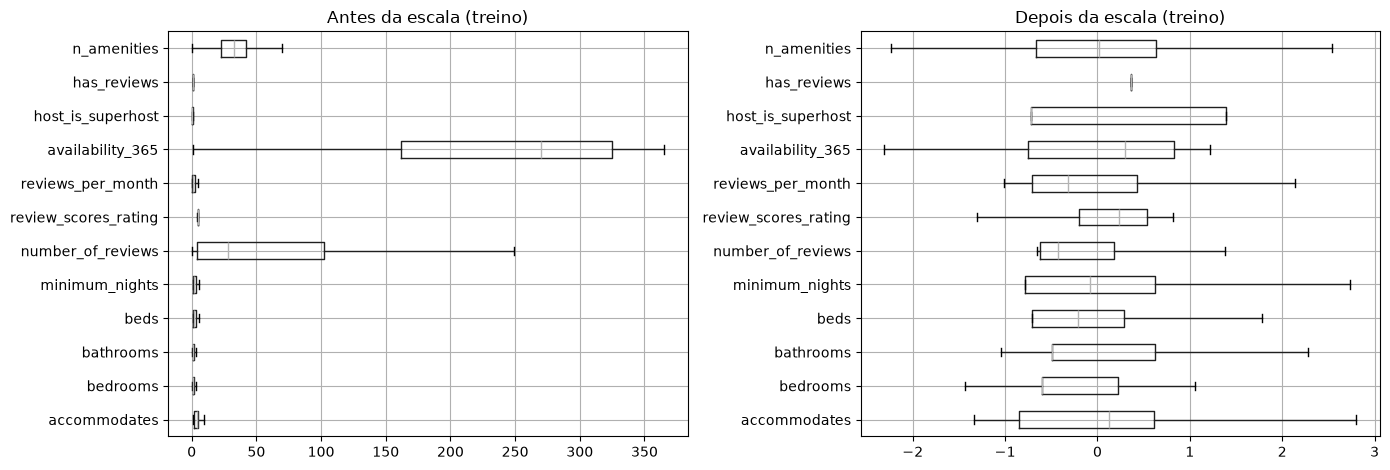

In [34]:
fig, eixos = plt.subplots(1, 2, figsize=(14, 4.8))
antes_escala.boxplot(ax=eixos[0], vert=False, showfliers=False)
eixos[0].set_title("Antes da escala (treino)")
train[colunas_para_escalar].boxplot(ax=eixos[1], vert=False, showfliers=False)
eixos[1].set_title("Depois da escala (treino)")
plt.tight_layout()
plt.show()

## 14. Gerar todas as combinações de pré-processamento

Reutiliza as funções já definidas nas secções anteriores (`limpar_price`, `limpar_percentagens_e_booleanos`, `criar_has_reviews`, `criar_n_amenities`, `agrupar_raras`, `split_treino_val_teste`, `calcular_limites_cap`/`aplicar_cap`/`detectar_outliers_mask`, `imputar_valores`, `codificar_categoricas`, `escalar_numericas`): nada é reescrito, só orquestrado numa função que corre para todas as combinações e guarda cada uma em `data_prepared/<missing>_<outlier>/`.

In [35]:
def preparar_e_guardar(df_bruto, missing_strategy, outlier_strategy, outdir):
    df = df_bruto.copy()
    df = df.drop(columns=df.columns[df.isna().all()])
    df = limpar_price(df)
    df = limpar_percentagens_e_booleanos(df)

    numeric_cols_local, categorical_cols_local = selecionar_variaveis(df)

    df = criar_has_reviews(df)
    df = criar_n_amenities(df)
    numeric_cols_local = numeric_cols_local + ["has_reviews", "n_amenities"]

    if "property_type" in df.columns:
        df = agrupar_raras(df, "property_type", top_n=10)
    if "neighbourhood_cleansed" in df.columns:
        df = agrupar_raras(df, "neighbourhood_cleansed", top_n=15)

    numeric_cols_local = list(dict.fromkeys(c for c in numeric_cols_local if not df[c].isna().all()))

    df = definir_target(df)
    tr, va, te = split_treino_val_teste(df)

    if outlier_strategy == "cap":
        limites = calcular_limites_cap(tr, OUTLIER_COLS)
        tr, va, te = aplicar_cap(tr, limites), aplicar_cap(va, limites), aplicar_cap(te, limites)
    elif outlier_strategy == "drop":
        mask = detectar_outliers_mask(tr, OUTLIER_COLS)
        tr = tr[~mask].copy()

    tr, va, te = imputar_valores(tr, va, te, numeric_cols_local, missing_strategy)
    tr, va, te, colunas_dummy_local = codificar_categoricas(tr, va, te, categorical_cols_local)

    feature_cols_local = [c for c in dict.fromkeys(numeric_cols_local + colunas_dummy_local) if c in tr.columns]
    tr, va, te = escalar_numericas(tr, va, te, numeric_cols_local)  # dummies ficam 0/1, sem escala

    for d in (tr, va, te):
        d["log_price"] = np.log1p(d["price"])

    os.makedirs(outdir, exist_ok=True)
    for nome, d in [("train", tr), ("val", va), ("test", te)]:
        d[feature_cols_local].to_csv(f"{outdir}/X_{nome}.csv", index=False)
        d[["price", "log_price", "high_price"]].to_csv(f"{outdir}/y_{nome}.csv", index=False)

    return len(feature_cols_local)

In [36]:
df_bruto = pd.read_csv(INPUT_PATH)

for missing_strategy in ["simple", "grouped"]:
    for outlier_strategy in ["none", "cap", "drop"]:
        pasta = f"data_prepared/{missing_strategy}_{outlier_strategy}"
        n_features = preparar_e_guardar(df_bruto, missing_strategy, outlier_strategy, pasta)
        print(f"{pasta}: {n_features} features guardadas")

Removidas 2240 linhas sem preço válido.
data_prepared/simple_none: 43 features guardadas
Removidas 2240 linhas sem preço válido.
data_prepared/simple_cap: 43 features guardadas
Removidas 2240 linhas sem preço válido.
data_prepared/simple_drop: 43 features guardadas
Removidas 2240 linhas sem preço válido.
data_prepared/grouped_none: 43 features guardadas
Removidas 2240 linhas sem preço válido.
data_prepared/grouped_cap: 43 features guardadas
Removidas 2240 linhas sem preço válido.
data_prepared/grouped_drop: 43 features guardadas


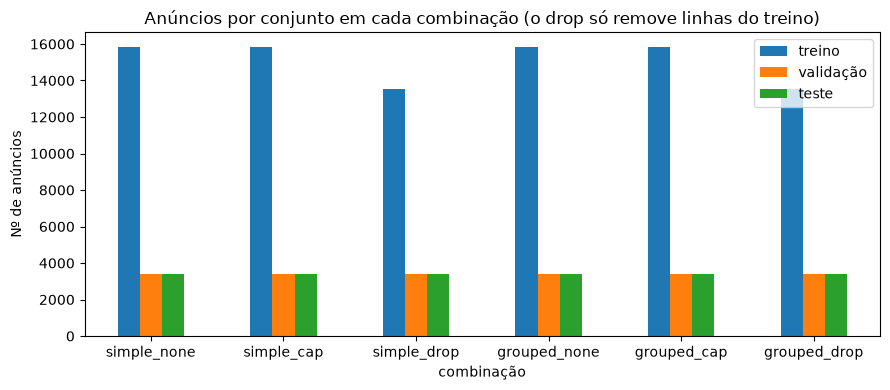

In [37]:
linhas = []
for missing_strategy in ["simple", "grouped"]:
    for outlier_strategy in ["none", "cap", "drop"]:
        pasta = f"data_prepared/{missing_strategy}_{outlier_strategy}"
        linhas.append({
            "combinação": f"{missing_strategy}_{outlier_strategy}",
            "treino": len(pd.read_csv(f"{pasta}/y_train.csv")),
            "validação": len(pd.read_csv(f"{pasta}/y_val.csv")),
            "teste": len(pd.read_csv(f"{pasta}/y_test.csv")),
        })
tabela_combos = pd.DataFrame(linhas).set_index("combinação")
tabela_combos.plot(kind="bar", figsize=(9, 4), rot=0)
plt.ylabel("Nº de anúncios")
plt.title("Anúncios por conjunto em cada combinação (o drop só remove linhas do treino)")
plt.tight_layout()
plt.show()